In [1]:
import addons
import numpy as np
import pandas as pd 
import os
import helpers
import random
import math
import matplotlib.pyplot as plt 
from matplotlib.patches import Polygon
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation

/home/hyc_1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:21:32

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
def filter_signal(data,fs,lowcut,highcut,order=3):
    filtered_signal = {}
    for i in range(len(data)):
        try:
            filtered_signal[i] = addons.butter_bandpass_filter(data[i]-np.mean(data[i]),lowcut,highcut,fs,order)
        except:
            filtered_signal[i] = data[i]

    return filtered_signal

In [3]:
def filter_signal_2(data,fs,lowcut,highcut,order=3):
      return addons.butter_bandpass_filter(data-np.mean(data),lowcut,highcut,fs,order)

In [4]:
from scipy.sparse import dok_matrix 
from scipy.fft import fft
from scipy.fft import fftfreq
from scipy import signal
from scipy.signal import butter, lfilter
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def compute_FFT(signal_data,name_,rate,freq_sample= 0.001,freq_sample_welsh = 1000,lim_y = 7000, lim_x = 200, low_log = 10, high_log =90,fit=False,fit_freq_start = 4.0, fit_freq_end = 14.0,test_p0 = [3000,40,5],welsh_fit = 'alpha',signal_xmin=500,signal_xmax=900,min_x=1,save=True,savefig=False,name_2=None,optional_plot=None):

    plt.rcParams.update({'font.size': 22})
    analysis_interval_start = addons.analysis_dict["analysis_start"]
    analysis_interval_end = addons.analysis_dict["analysis_end"]
    analysis_interval_start = int(analysis_interval_start)
    analysis_interval_end = int(analysis_interval_end)
    times_currents = np.linspace(addons.analysis_dict["analysis_start"],addons.analysis_dict["analysis_end"],num=int((addons.analysis_dict["analysis_end"]-addons.analysis_dict["analysis_start"])))

    FFT_Results = {}
    Welsh_Freqs = {}
    Welsh_Powers = {}
    if fit:
        Fit_FFT = {}
        Fit_Welsh = {}
        mean_freq = []
        mean_welsh = []
        amplitude_freq = []
        amplitude_welsh = []
        sigma_freq = []
        sigma_welsh = []
        def gaus(x, a, x0, sigma):
            return a*np.exp(-(x-x0)**2/(2*sigma**2))

    FFT_Results= fft(signal_data[analysis_interval_start:analysis_interval_end]-np.mean(signal_data[analysis_interval_start:analysis_interval_end]))
    #Welsh_Freqs, Welsh_Powers  = signal.welch(signal_data[analysis_interval_start:analysis_interval_end]-np.mean(signal_data[analysis_interval_start:analysis_interval_end]),fs=freq_sample_welsh)

    #Calcular los valores de frequencia correspondientes
    #freq = fftfreq(len(signal_data[i][analysis_interval_start:analysis_interval_end]),d=freq_sample) * 1000
    freq = fftfreq(len(signal_data[analysis_interval_start:analysis_interval_end]),d=freq_sample)
    if fit:
        index_start = int(np.where(freq==fit_freq_start)[0][0])
        index_end = int(np.where(freq==fit_freq_end)[0][0])
    

    plt.figure(figsize=(25, 15))
    colors = ['#d53e4f', '#f46d43', '#fdae61', '#fee08b', '#e6f598', '#abdda4', '#66c2a5', '#3288bd']
    pops = ["L23E","L23I","L4E","L4I","L5E","L5I","L6E","L6I"]
    # Graficar la amplitud en función de la frecuencia
    colors_filter = ['#d53e4f', '#3288bd']


    plt.subplot(2, 1, 1)
    j= 0
    if optional_plot is not None:
        for i in signal_data:
            if i == 0 or i == 2:
                #plt.plot(times_currents,optional_plot[i][analysis_interval_start:analysis_interval_end], c = colors_filter[j], label = pops[i], alpha = 0.5)
                #plt.plot(times_currents,signal_data[i][analysis_interval_start:analysis_interval_end], '--', c = colors_filter[j])
                plt.plot(times_currents,optional_plot[i], c = colors_filter[j], label = pops[i], alpha = 0.5)
                plt.plot(times_currents,signal_data[i], '--', c = colors_filter[j])
                j=j+1
        plt.xlabel('time [ms]')
        plt.ylabel('population activity [spikes]')
        plt.title('background rate  = ' +str(rate))
        plt.xlim(signal_xmin,signal_xmax)    
        plt.grid(True)
        #plt.legend(loc= 'best')
        plt.legend(loc= 'upper left')
        plt.subplot(2, 2, 3)
        j= 0


    else:
            #plt.plot(times_currents,signal_data[i][analysis_interval_start:analysis_interval_end], c = colors[j], label = pops[i])
        plt.plot(times_currents,signal_data[analysis_interval_start:analysis_interval_end], c = colors[j])
        plt.xlabel('time [ms]')
        plt.ylabel('population activity [spikes]')
        plt.title('background rate  = ' +str(rate))
        plt.xlim(signal_xmin,signal_xmax)    
        plt.grid(True)
        #plt.legend(loc= 'best')
        plt.legend(loc= 'upper left')
        plt.subplot(2, 2, 3)
        j= 0

    indx = int(len(signal_data[analysis_interval_start:analysis_interval_end])/2)
    if fit:
        try:
            Fit_FFT[i], __ = curve_fit(gaus,freq[index_start:index_end],np.abs(FFT_Results[index_start:index_end]),p0 = test_p0)
        except RuntimeError:
            print("Error in curve fitting for index:", i)
        Fit_FFT[i] = [0, 0, 0]
        if Fit_FFT[i][1] <= 0:
            Fit_FFT[i][1] = 0
            Fit_FFT[i][0] = 0
        if Fit_FFT[i][1] >= 15 and welsh_fit == 'alpha':
            Fit_FFT[i][1] = 0
            Fit_FFT[i][0] = 0
        mean_freq = np.append(mean_freq,Fit_FFT[i][1])
        amplitude_freq = np.append(amplitude_freq,Fit_FFT[i][0])
        sigma_freq = np.append(sigma_freq,Fit_FFT[i][2])

        plt.plot(freq[index_start:index_end],gaus(freq[index_start:index_end],*Fit_FFT[i]),'--', c = colors[j])
    plt.plot(freq[:indx], np.abs(FFT_Results[:indx]),c = colors[2])
    #plt.plot(Welsh_Freqs[:indx], np.abs(Welsh_Powers[:indx]),c = colors[2])
    j=j+1
    plt.xlabel('frequency [Hz]')
    plt.ylabel('ampltidue [spikes]')
    plt.figtext(0.5,0.48,"Fast Fourier Transform", va="center", ha="center", size=22)
    plt.grid(True)
    plt.xlim(min_x,lim_x)
    #plt.ylim(0,lim_y)
    #plt.legend(loc= 'best')

    plt.subplot(2, 2, 4)
    j= 0
    indx = int(len(signal_data[analysis_interval_start:analysis_interval_end])/2)
    for i in FFT_Results:
        if fit:
            plt.plot(freq[index_start:index_end],20 * np.log10(gaus(freq[index_start:index_end],*Fit_FFT[i])),'--', c = colors[j])
        plt.plot(freq[:indx], 20 * np.log10(np.abs(FFT_Results)[:indx]),c = colors[2])
        #plt.plot(Welsh_Freqs[:indx], 20 * np.log10(np.abs(Welsh_Powers)[:indx]),c = colors[2])
        j=j+1
    plt.xlabel('frequency [Hz]')
    plt.ylabel('amplitude [dB]')
    #plt.title('Voltage (minus the mean) FFT')
    plt.grid(True)
    plt.xlim(min_x,lim_x)
    plt.ylim(low_log,high_log)

    result_fourier = {}

    result_fourier = np.abs(FFT_Results)[:indx]
    results_freq = freq[:indx]
    if savefig:
        if save:
            if welsh_fit == 'alpha':
                name = name_2 + '/results/fft_alpha.svg'
            elif welsh_fit == 'gamma':
                name = name_2 + '/results/fft_gamma.svg'
        else:
            name = name_2 + '/results/fft.svg'
            if not os.path.exists(name_2 + '/results/'):
                os.makedirs(name_2 + '/results/')
        plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.close()

    if save:
        pops = [0,1,2,3,4,5,6,7]
        #np.savetxt(name_, np.c_[pops,mean_freq, amplitude_freq, sigma_freq, mean_welsh,amplitude_welsh,sigma_welsh], fmt = '%.2f', header = 'Pops mean_freq amplitude sigma mean_welsh amplitude_welsh sigma_welsh', delimiter = ' ')
        np.savetxt(name_, np.c_[pops,mean_freq, amplitude_freq, sigma_freq], fmt = '%.2f', header = 'Pops mean_freq amplitude sigma', delimiter = ' ')

    return result_fourier, results_freq, Welsh_Freqs, Welsh_Powers, indx
    #return Welsh_Freqs, Welsh_Powers, result_fourier, results_freq, indx

In [5]:
#super_name = 'data_background_rate_big'
super_name = 'data_background_rate_big_3'

In [ ]:
net_dict = addons.analysis_dict

list_dirs = os.listdir(super_name)
list_dirs = sorted(list_dirs)


names = ["L23E", "L23I", "L4E", "L4I", "L5E", "L5I", "L6E", "L6I"]


lowcut_alpha = 5
highcut_alpha =15

lowcut_gamma = 20
highcut_gamma = 40

freq_sample = 0.001
fs_sampling = 5000
freq_sample_welsh = 5000

for i, dir in enumerate(list_dirs[0:1]): #changed due to kernel problems, it was on 49, which corresponds to 17.46, kernel brok in 9,49
    name = super_name + "/" + str(dir)
    list_dirs_2 = os.listdir(name)
    #print(dir)
    try:
        list_dirs_2.remove('results')
    except ValueError:
        pass
    list_dirs_2 = sorted(list_dirs_2)
    for j, dir_2 in enumerate(list_dirs_2):
        name_2 = name + '/' + str(dir_2) + "/"
        neuron_id = np.loadtxt((os.path.join(name_2,"population_nodeids.dat")),dtype=int)
        num_neurons = []
        for l in range(len(neuron_id)):
            num_neurons = np.append(num_neurons,int(neuron_id[l][1]-neuron_id[l][0]+1))
        num_neurons = num_neurons.astype(int)
        test  = addons.load_data(name_2,'ex_current',type="Current")
        test_b = addons.load_data(name_2,'in_current',type="Current")

        test_3 = {}
        m = 0
        for l in range(len(test)):
            if l %2 == 0:
                test_2 = addons.split_data(test[l],num_neurons[l],type="Current")
                test_2b = addons.split_data(test_b[l],num_neurons[l],type="Current")
                test_3[m] = np.abs(test_2) + np.abs(test_2b)
                m += 1

        frac_neurons = {}
        means = {}
        m = 0
        for l in range(len(num_neurons)):
            if l %2 == 0:
                frac_neurons[m] = num_neurons[l] / np.sum(num_neurons)
                means[m] = np.mean(test_3[m],axis=0)
                m += 1

        final_sum = np.zeros_like(means[0])
        for l in range(len(means)):
            final_sum = final_sum + (means[l] * frac_neurons[l])
        final_sum = final_sum / 4

        Fourier_signal, FFT_frequencies, Welsh_frequencies, Welsh_signal, FFT_index  = compute_FFT(final_sum,name_=name_2,rate=dir,lim_y=400000,lim_x=100,high_log=130,low_log=0,freq_sample=freq_sample,freq_sample_welsh=freq_sample_welsh,signal_xmax=1500,save=False,savefig=True,name_2=name_2)

In [6]:

list_dirs = os.listdir(super_name)
list_dirs = sorted(list_dirs)

names = ["L23E", "L23I", "L4E", "L4I", "L5E", "L5I", "L6E", "L6I"]
num_trials = 1
freq_sample = 0.001
fs_sampling = 5000
freq_sample_welsh = 5000


for i, dir in enumerate(list_dirs): #changed due to kernel problems, it was on 49, which corresponds to 17.46, kernel brok in 9,49
    name = super_name + "/" + str(dir)
    list_dirs_2 = os.listdir(name)
    #print(dir)
    try:
        list_dirs_2.remove('results')
    except ValueError:
        pass
    list_dirs_2 = sorted(list_dirs_2)
    for j, dir_2 in enumerate(list_dirs_2):
        name_2 = name + '/' + str(dir_2) + '/'
        if os.path.isfile(name_2 + "/results/mean_current.txt"):
            continue
        neuron_id = np.loadtxt((os.path.join(name_2,"population_nodeids.dat")),dtype=int)
        num_neurons = []
        for l in range(len(neuron_id)):
            num_neurons = np.append(num_neurons,int(neuron_id[l][1]-neuron_id[l][0]+1))
        num_neurons = num_neurons.astype(int)
        test  = addons.load_data(name_2,'ex_current',type="Current")
        test_b = addons.load_data(name_2,'in_current',type="Current")

        test_3 = {}
        m = 0
        for l in range(len(test)):
            if l %2 == 0:
                test_2 = addons.split_data(test[l],num_neurons[l],type="Current")
                test_2b = addons.split_data(test_b[l],num_neurons[l],type="Current")
                test_3[m] = np.abs(test_2) + np.abs(test_2b)
                m += 1

        frac_neurons = {}
        means = {}
        m = 0
        for l in range(len(num_neurons)):
            if l %2 == 0:
                frac_neurons[m] = num_neurons[l] / np.sum(num_neurons)
                means[m] = np.mean(test_3[m],axis=0)
                m += 1

        final_sum = np.zeros_like(means[0])
        for l in range(len(means)):
            final_sum = final_sum + (means[l] * frac_neurons[l])
        final_sum = final_sum / 4
        np.savetxt(name_2 + "/results/mean_current.txt", final_sum, fmt = '%.2f', header = 'mean_current', delimiter = ' ')

In [9]:

list_dirs = os.listdir(super_name)
list_dirs = sorted(list_dirs)

names = ["L23E", "L23I", "L4E", "L4I", "L5E", "L5I", "L6E", "L6I"]
num_trials = 1
freq_sample = 0.001
fs_sampling = 5000
freq_sample_welsh = 5000

Fourier_data = np.zeros((len(list_dirs),num_trials,1,2250))
Fourier_data_final = np.zeros((len(list_dirs),1,2250))

store_data = {}

for i, dir in enumerate(list_dirs):
    name = super_name + "/" + str(dir)
    list_dirs_2 = os.listdir(name)
    try:
        list_dirs_2.remove('results')
    except ValueError:
        pass
    list_dirs_2 = sorted(list_dirs_2)
    for j, dir_2 in enumerate(list_dirs_2):
        name_2 = name + '/' + str(dir_2) + '/'
        final_sum = np.loadtxt(name_2 + "/results/mean_current.txt", dtype=float)
        store_data[i] = final_sum
        Fourier_data_help, FFT_frequencies, Welsh_frequencies, Welsh_signal, FFT_index  = compute_FFT(final_sum,name_=name_2,rate=dir,lim_y=400000,lim_x=100,high_log=130,low_log=0,freq_sample=freq_sample,freq_sample_welsh=freq_sample_welsh,signal_xmax=1500,save=False,savefig=True,name_2=name_2)
        Fourier_data[i,j,:,:] = Fourier_data_help
    Fourier_data_final[i,:,:] = np.mean(Fourier_data[i,:,:,:],axis=0)

/tmp/ipykernel_897287/1643165620.py:81: UserWarning:No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [10]:
store_data = np.array(list(store_data.values()))

In [11]:
import numpy as np

def NormalizeData(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

Text(0.5, 1.0, 'FFT of an LFP proxy')

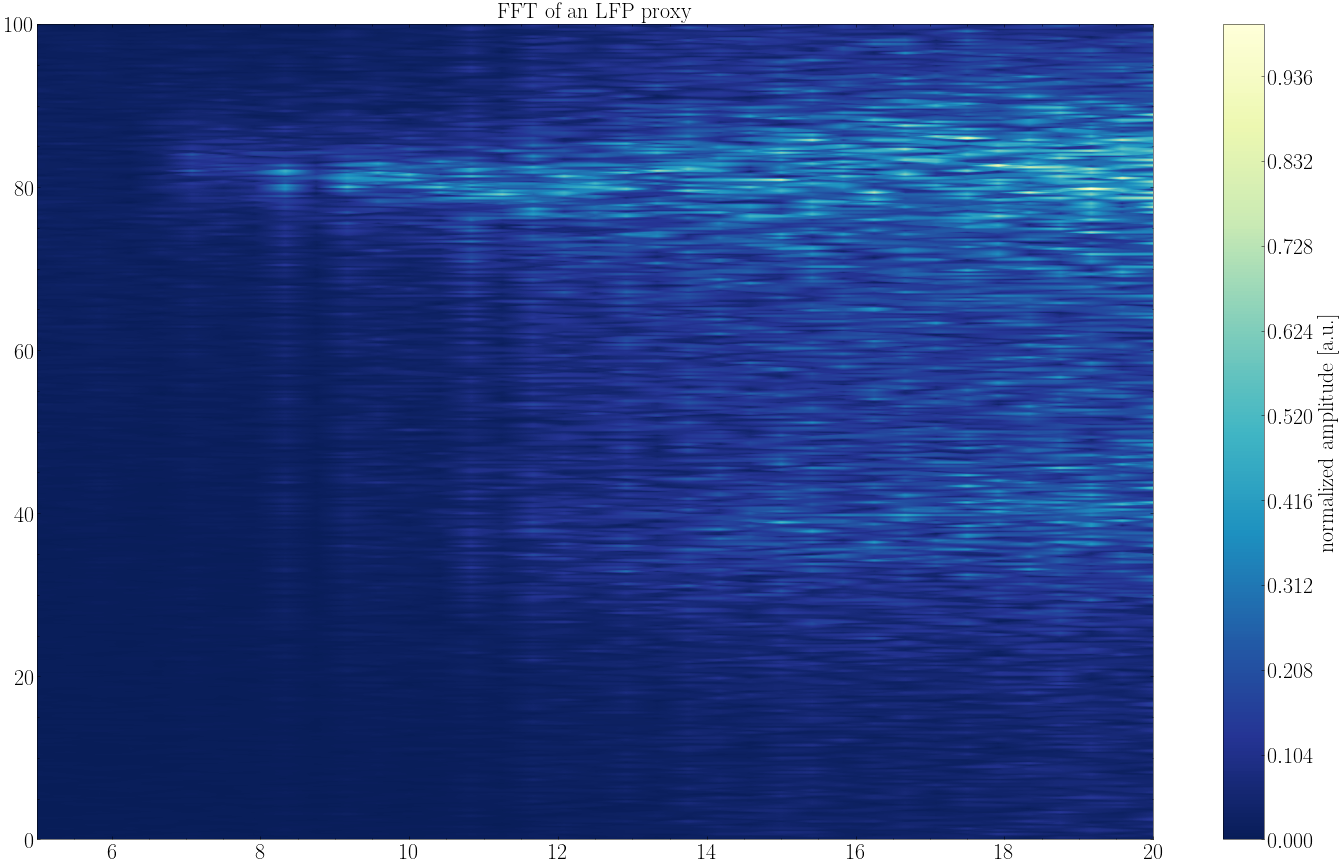

In [12]:
plt.figure(figsize=(25, 15))
fs = 22
bg_rates = np.linspace(5,20,len(list_dirs))
plt.contourf(bg_rates,FFT_frequencies,np.transpose(NormalizeData(Fourier_data_final[:,0,:])), levels=300, cmap='YlGnBu_r')
plt.ylim(top=100)
plt.colorbar(label='normalized amplitude [a.u.]')
plt.title('FFT of an LFP proxy', fontsize=fs)

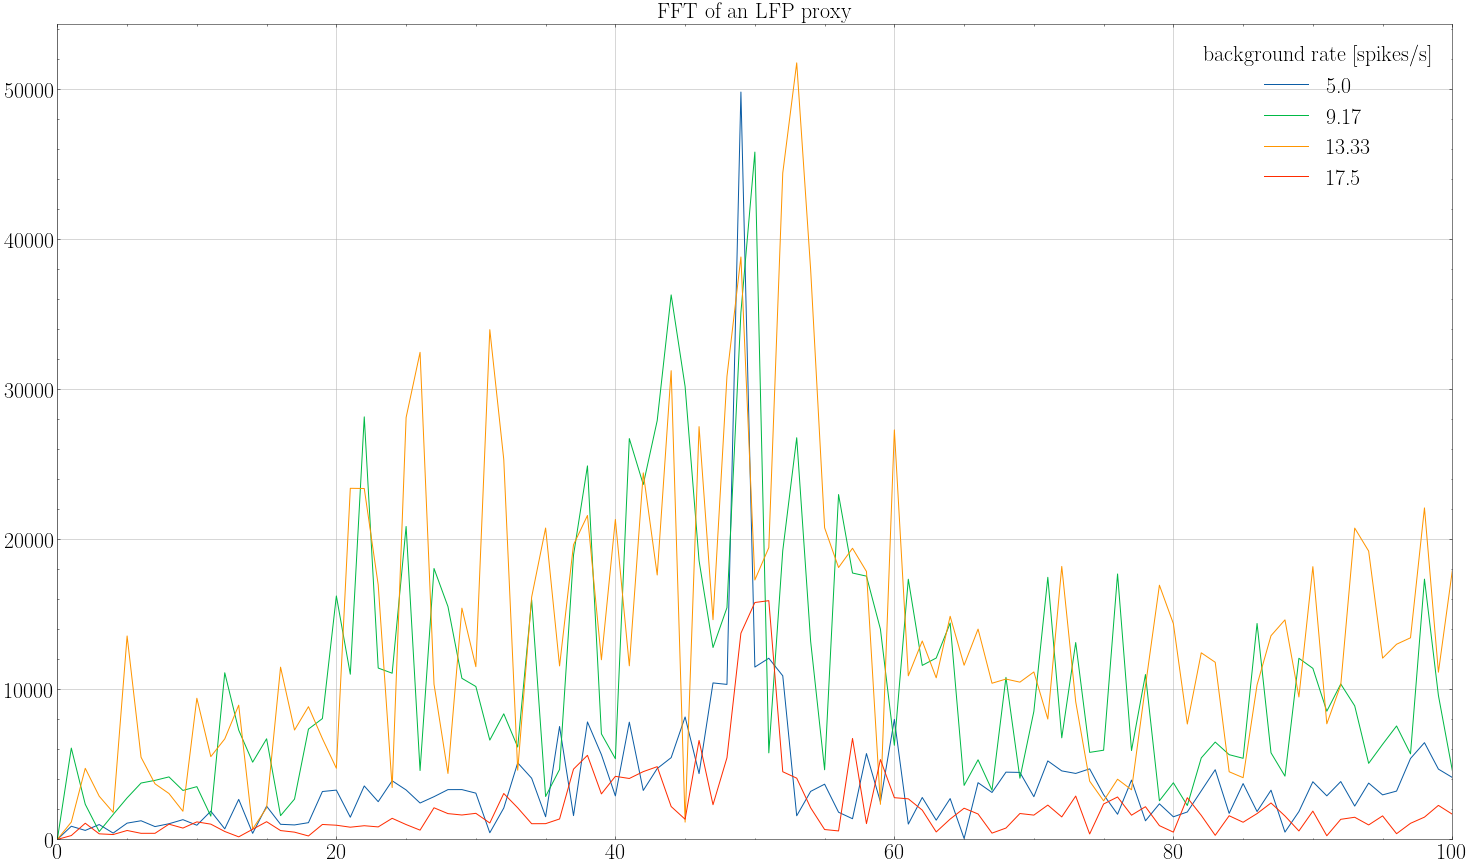

In [14]:
plt.figure(figsize=(25, 15))
plt.plot(Fourier_data_final[0][0],label = round(bg_rates[0],2))
plt.plot(Fourier_data_final[10][0],label = round(bg_rates[10],2))
plt.plot(Fourier_data_final[20][0],label = round(bg_rates[20],2))
plt.plot(Fourier_data_final[30][0],label = round(bg_rates[30],2))
plt.legend(loc='upper right',title='background rate [spikes/s]')
plt.title('FFT of an LFP proxy', fontsize=fs)
plt.xlim(0,100)
plt.ylim(bottom=0)
plt.grid()

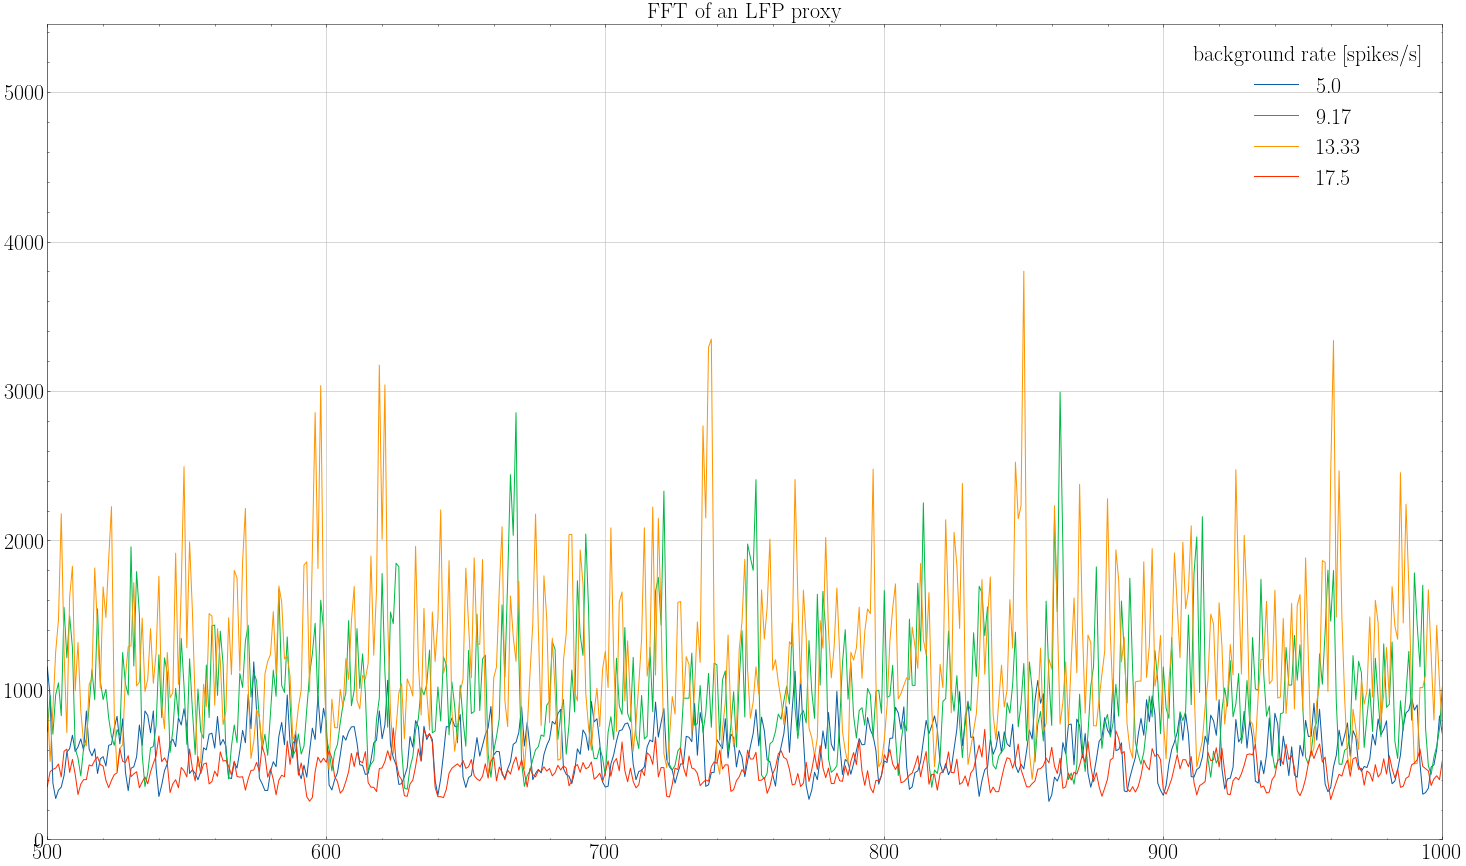

In [15]:
plt.figure(figsize=(25, 15))
plt.plot(store_data[0],label = round(bg_rates[0],2))
plt.plot(store_data[10],label = round(bg_rates[10],2))
plt.plot(store_data[20],label = round(bg_rates[20],2))
plt.plot(store_data[30],label = round(bg_rates[30],2))
plt.legend(loc='upper right',title='background rate [spikes/s]')
plt.title('FFT of an LFP proxy', fontsize=fs)
plt.xlim(500,1000)
plt.ylim(bottom=0)
plt.grid()